In [113]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [85]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [86]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [87]:
llm.invoke("How are you").content

"I'm just a computer program, so I don't have feelings, but I'm here and ready to help you! How can I assist you today?"

In [88]:
from typing import TypedDict, Annotated,List,Union
import operator

In [89]:
from langchain_core.messages import AnyMessage, HumanMessage,AIMessage

In [90]:
class AgentState(TypedDict):
    messages : Annotated[list[AnyMessage], add_messages]

In [91]:
def llm_call(state:AgentState)->AgentState:
    '''Call the LLM using conversation messages and append the AI message'''
    response = llm.invoke(state['messages'])
    state["messages"].append(AIMessage(content=response.content))
    return state

In [92]:
def token_counter(state: AgentState)-> AgentState:
    '''Count the number of token generated by the AI response'''
    last_message = state['messages'][-1]
    text = last_message.content
    text_length = len(text.split())
    summary = f"Total number of tokens in the generated answer is {text_length}"
    state["messages"].append(AIMessage(content=summary))
    return state

In [93]:
graph = StateGraph(AgentState)
graph.add_node("llm_call",llm_call)
graph.add_node("token_counter",token_counter)

In [94]:
graph.set_entry_point("llm_call")
graph.add_edge("llm_call","token_counter")
graph.set_finish_point("token_counter")
app = graph.compile()

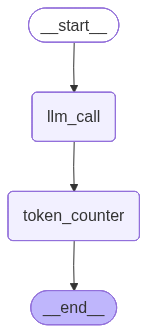

In [95]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))


In [96]:
result = app.invoke({"messages": [HumanMessage(content="Hello how are you")]})   

In [97]:
result

{'messages': [HumanMessage(content='Hello how are you', additional_kwargs={}, response_metadata={}, id='89878c7d-45d1-4da1-8aa4-07fb1f7c1770'),
  AIMessage(content="Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?", additional_kwargs={}, response_metadata={}, id='55e107b2-583f-46f4-970a-2648fef20f31', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='Total number of tokens in the generated answer is 24', additional_kwargs={}, response_metadata={}, id='a6ecefd9-1900-48b0-88d7-4d71b09d5937', tool_calls=[], invalid_tool_calls=[])]}

In [98]:
res = app.invoke({"messages": [HumanMessage(content="What is the plan for tomorrow")]})   

In [99]:
res

{'messages': [HumanMessage(content='What is the plan for tomorrow', additional_kwargs={}, response_metadata={}, id='a95c40a2-d6c6-40c3-bd13-f1693af1c220'),
  AIMessage(content="I don't have access to real-time information or personal schedules, so I can't provide specific plans for tomorrow. However, if you have something in mind or need help organizing your day, feel free to share, and I can help you brainstorm or create a plan!", additional_kwargs={}, response_metadata={}, id='544f4623-098f-4f5c-b4dc-9e6506ba61e0', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='Total number of tokens in the generated answer is 45', additional_kwargs={}, response_metadata={}, id='29374bf6-1fc5-43b5-b3f6-bb3007b70d82', tool_calls=[], invalid_tool_calls=[])]}

In [101]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [109]:
api_wrapper = WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max=500)

In [110]:
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

In [111]:
wiki_tool.invoke({"query":"Generative AI"})

'Page: Generative AI\nSummary: Generative artificial intelligence (GenAI) is a subfield of artificial intelligence (AI) that uses generative models to generate text, images, videos, audio, software code (vibe coding) or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI tools has increased significantly s'

In [116]:
from langchain_community.tools.tavily_search import TavilySearchResults
import os
TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')

In [117]:
tavily_tool = TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

/var/folders/88/p2ppv1mj0d1078cjs408f6ch0000gn/T/ipykernel_30190/1291469283.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(tavily_api_key=TAVILY_API_KEY)


In [121]:
tavily_tool.invoke({"query":"How is the job market for fresher graduate in 2026"})


[{'title': 'From Graduation to Career: Job Market Trends for 2026 - CHC Blog',
  'url': 'https://www.diplomaframe.com/chc-blog/from-graduation-to-career-job-market-trends-for-2025',
  'content': '## Final Words\n\nFor fresh graduates, the world of employment looks bright and promising. However, it also comes with uncertainties and apprehensions—not when you stay abreast with the employment trends in 2026! Consider the job market trends above—from the rise of AI, the gig economy, and business sustainability to the demands for soft and hard skills. Likewise, take into account niche-specific evolution in your industry or chosen profession. Lastly, follow our crucial steps for preparing yourself for employment. With all these in mind, you can set yourself up for professional growth and career success! [...] ## Job Market Trends To Consider in 2026\n\nSurpassing the academic years is no easy feat. So, graduating from college is outright fulfilling and rewarding. This means you can already f

In [123]:
from langchain_community.tools import DuckDuckGoSearchRun
search = DuckDuckGoSearchRun()

In [124]:
search.invoke("What is the latest update about on iphone18 release")

"15 hours ago ... Apple is set to release the iPhone 18 lineup this fall, including a new iPhone 18 Pro Max ... As we await the iPhone 18 — and its updated operating system ... May 1, 2026 ... Apple's iPhone 18 Series is COMING very soon including the iPhone Ultra. Here are 10 Leak Updates! AirPods Pro 3 on Amazon ➡ https://geni.us/f8Oxp Buy ... Jun 26, 2026 ... Timeline. Fall 2026: iPhone 18 Pro, Pro Max, and Fold; Spring 2027: iPhone 18, 18e, and perhaps Air 2. Roundup Last Updated 3 weeks ago ... new iPhone models as ... Apr 3, 2026 ... How would literally anyone here be able to answer that? Obviously we all know they hold back features intentionally, but the yearly release cadence is also ... Jul 7, 2026 ... Bloomberg has reported that Apple plans to release the more expensive iPhone 18 Pro, the iPhone 18 Pro Max and its new foldable in fall 2026, while the more ..."

YOUTUBE SEARCH TOOL

In [125]:
from langchain_community.tools import YouTubeSearchTool

In [126]:
tool = YouTubeSearchTool()

In [127]:
tool.name

'youtube_search'

In [128]:
tool.description

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

In [129]:
tool.run("krish naik")

"['https://www.youtube.com/watch?v=bPrmA1SEN2k&pp=ygUKa3Jpc2ggbmFpaw%3D%3D', 'https://www.youtube.com/watch?v=bjkjaqUZl4E&pp=ygUKa3Jpc2ggbmFpaw%3D%3D']"

In [5]:
from langchain_community.tools import tool

/var/folders/88/p2ppv1mj0d1078cjs408f6ch0000gn/T/ipykernel_19583/3868577644.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import tool


In [7]:
@tool
def multiply(a:int,b:int) -> int:
    '''Multiply 2 given numbers '''
    return a*b

In [8]:
multiply.invoke({"a":20,"b":30})

600

In [12]:
@tool
def get_word_length(word:str) -> int:
    '''Get the count of the no of words in the given string'''
    res = len(word.split())
    return res

In [13]:
get_word_length.invoke({"word":"Lorem Ipsum is simply dummy text of the printing and typesetting industry. Lorem Ipsum has been the industry's standard dummy text ever since 1966, when designers at Letraset and James Mosley, the librarian at St Bride Printing Library in London, took a 1914 Cicero translation and scrambled it to make dummy text for Letraset's Body Type sheets. It has survived not only many decades, but also the leap into electronic typesetting, remaining essentially unchanged. It was popularised thanks to these sheets and more recently with desktop publishing software like Aldus PageMaker and Microsoft Word including versions of Lorem Ipsum."})

99